# Assignment 2 $-$ Argument Acquisition
_Solutions have to be submitted in pairs of two by Monday, May 11th, 23:59 (UTC+2)._

**Grading:**
- This assignment is worth 30 points, you get points for running code without unhandled, preventable errors, correct outputs and answers to analysis questions
- **0 - *Fail*:** No submission; non-working code (preventable errors and exceptions); code that directly contradicts the task description or produces incorrect outputs; authorship violations like plagiarism or solutions fully or largely generated by AI

**Submission Components:**

- **Code:** Tasks 1 and 2
  - **Output Files:** Your submission should include the output files in the correct folder with the correct naming.
  - **Explanation:** You should add overall explanations of your code (i.e., modify/employ docstrings) and comments for individual implementation decisions.
- **Analysis:** Task 3 answered in full text with sensible formatting and using the results from task 2 explicitly.


**Submission Group:**
Alireza Naji, Austin Philip Paul

## Assignment Goals

### Motivation
To study arguments, we need arguments, which we can get from many places: comment sections (on news websites/social media), discussion or debate forums, deliberative democracy platforms, parliamentary proceedings (speeches, debates), talk shows ...

Acquiring and manually processing new data takes time and also often money, e.g., for manual annotation studies. Before collecting new data, it is thus usually worth checking what already exists and whether you are allowed to use it. Below is a simple workflow to finding data for any research project:

1. Check for existing datasets
    - Papers related to your topic (methods or goals)
    - Survey papers compiling datasets and resources on one topic
    - Platforms like Kaggle, HuggingfaceHub (datasets you find here often come with exact instructions and guides)
2. No luck? $\to$ Check usage restrictions
    - `robots.txt` files show bots which subpages (not) to crawl, below is an example from [kialo](https://kialo.com/robots.txt))
       ```
       User-agent: Googlebot
       Disallow:
       User-agent: *
       Disallow: /
       ```
    - API terms (e.g., [data API terms](https://redditinc.com/policies/data-api-terms))
3. If unsure, ask:
    - Check with the rights holders directly (e.g., contact form, email).
    - Never illicitly use data: you cannot publish your data/findings without academic/legal consequences, but most importantly, we do not want to exacerbate the problem of data hungry AI-companies using data that is private or copyrighted.

### Application

We now apply this to a common task in computational argumentation: **argument quality assessment**.

Process argumentative discussions scraped from [r/ChangeMyView](https://www.reddit.com/r/changemyview/) by [Tan et al. (2016)](https://doi.org/10.1145/2872427.2883081) into a dataset usable for the task. On the subreddit, people can post their genuine opinions (OPs) to be persuaded of the opposite. If they are persuaded, they award a $\Delta$ point to the persuasive comment.

In this assignment, you will create a new dataset suitable for training a model to perform the following task:

> **Persuasiveness Classification:** Given an argumentative text, predict its persuasiveness, i.e., if it was awarded a $\Delta$.
> 
> **Example:**
>
> Because of the fact that the Vice President is responsible for Presidential duties when the President is away means that they are the perfect person to take over for them. In the event of whatever emergency would surround the need for a VP to take the President's spot, the experience that the VP already has with their duties would mean they could easily step into the President's place without disrupting the rest of the cabinet, all of whom would likely be very busy with their current departments.
>
> $\Delta$
> 
> (OP Thread: *CMV: The position of Vice President of the United States should be eliminated from our government.*)

### Dataset Structure
The data was scraped from Reddit for [Tan et al. (2016)](https://doi.org/10.1145/2872427.2883081), thus, its format and encoded information directly match the output of the [Reddit API](https://redditinc.com/policies/data-api-terms). 

Start by exploring the data:

1. Visit the dataset's [homepage](https://chenhaot.com/papers/changemyview.html) to consult the Readme and Blog tutorial
2. Follow these instructions to extract the data from `cmv_reddit_api_data.jsonlist.bz2`, which is saved in `./data`.
3. Explore the data: what does an instance look like, which information is encoded, and how are comment threads stored?
   
Move on to the graded tasks once you are familiar with the dataset structure.

In [6]:
data_path = "data/cmv_reddit_api_data.jsonlist.bz2"

# YOUR CODE HERE

---

## Task 1

Extract all the posts from all the original threads into one dataset and save it.
- You should only include the following information: _post\_id, parent\_id, thread\_id, author, text, impact_votes, impact_persuasion_, and _persuasiveness_.
    - The first five features are identically named in the data, but the _impact_ features use the upvotes and author flair, respectively, and should be saved as positive integers (_- 1 point each_).
    - The _persuasiveness_ must be extracted as a $\Delta$ in the comment's replies and saved as a binary score (0 or 1) (_- 3 points_).
- Add all comments to a `pandas.DataFrame` with column names _exactly_ matching the above list of features (_- 1 point per error_). 
- Make sure that you only include posts that are usable for prediction, i.e., posts with unique, non-empty text fields (_- 3 points_).
- Save the DataFrame to a cvs `./outputs/posts.csv` file _without_ including the index (_1 point_).

<div style="text-align: right"><b>10 points</b></div>

In [7]:
import pandas as pd
import json
import bz2

bots=["AutoModerator", "subredditreports"]
posts={}

'''
There were some comments which didnt have text, author and it's children was either pointing to itself or pointing to an id which seems to be not in this dataset
There were some values which had no body, body as [deleted], author [deleted]
If author is deleted, then wen no need that row as that won't be persuasive. Delta bot mentions the author for delta awarded but if author is not there then not able to assign
If parent id and thread id is same then the parent is the OP comment. Need to remove t3_
some flair values start with infintiy and it is only for DeltaBot and since we remove it, not handling except make it 0.
parent id of first thread starts with t3 then all children parent id starts with t1
some posts have -ve ups, -ve score but downs only as zer0. so converted the negative values to zero.
We check deltabots which starts with Confirmed message and persuasiveness becomes 1 else 0
We remove rows with author deleted and persuasiveness 0. For persuasuiveness 1, we restore author name from DeltaBot message.
'''

def process_author_flair(text):
    if(text is None):
        return 0
    else:
        i=0
        flair_value=""
        while(i < len(text) and text[i].isnumeric()):
            flair_value += text[i]
            i+=1
        return int(flair_value or 0)

def process_delta_persuasiveness(parent_id, text):
    delta = 0
    name=""
    if(text.startswith("Confirmed")):
        delta = int(text[10:].split()[0])
        name = text[29:].split()[0].split('/')[-1][:-1]
    
    parent_post_id = parent_id.split("_")[1]
    grandparent = posts[parent_post_id]["parent_id"].split("_")[1]
    
    posts[grandparent]["persuasiveness"] = (lambda x: 1 if x>0 else 0)(delta)
    if(posts[grandparent]["author"] == "[deleted]" and delta>0):
        posts[grandparent]["author"] = name

def process_comments(comments):
    lines=[]
    for comment in comments:
        if("body" in comment):
            post_details = ({ 
                "post_id": comment["id"], 
                "parent_id": comment["parent_id"],
                "thread_id": comment["link_id"],
                "author": comment["author"],
                "text": comment["body"].strip(),
                "impact_votes": (lambda x: x if x>=0 else 0)(int(comment["ups"])),
                "impact_persuasion": process_author_flair(comment["author_flair_text"]),
                "persuasiveness": 0
                })
            
            if(comment["author"] == "DeltaBot"):
                process_delta_persuasiveness(comment["parent_id"], comment["body"])
                continue
    
            posts[comment["id"]] = post_details

def process_dataset():
    lines = []
    
    with bz2.open(data_path, "rt") as bzinput:
        for i, line in enumerate(bzinput):
            post = json.loads(line)

            if(post["author"] in bots):
                continue
            post_details = ({ 
                "post_id": post["id"],
                "parent_id": "",
                "thread_id": post["id"],
                "author": post["author"],
                "text": post["selftext"].strip(),
                "impact_votes": (lambda x: x if x>=0 else 0)(int(post["ups"])),
                "impact_persuasion": process_author_flair(post["author_flair_text"]),
                "persuasiveness": 0                         
                })

            posts[post["id"]] = post_details
            process_comments(post["comments"])
            
    return list(posts.values())

dataset=[]
dataset = process_dataset()

df = pd.DataFrame(data=dataset, columns=[ "post_id", "parent_id", "thread_id", "author", "text", "impact_votes", "impact_persuasion", "persuasiveness"])

df["text"] = df["text"].fillna("").astype(str)
df["parent_id"] = df["parent_id"].fillna("").astype(str)
df = df[df["text"].str.strip() != ""]
df = df[~(df["author"] == "DeltaBot")]
df = df[df["text"] != "[deleted]"]
df = df[~((df["author"] == "[deleted]") & (df["persuasiveness"] == 0) & (df["parent_id"] != ""))]
df = df.drop_duplicates(subset="text")

df.to_csv('./outputs/posts.csv', index=False)

---

## Task 2 $-$ Data Exploration

Now that we have the data, we can analyze discussion and interaction patterns with regards to persuasiveness. For this, we first need to calculate relevant metrics and statistics. In the following task, you will calculate different data statistics from your extracted DataFrame and then display them in a sensible way.

### 2.1 Persuasion Patterns
First we want to find patterns in persuasion behavior. For this we will divide the threads into successful from unsuccessful persuasion attempts based on the occurrence of $\Delta$'s in the threads. Then, we can compare user behavior between these two sets.

1. What is the ratio of threads with at least one $\Delta$-awarded comment? (_1 point_)
2. What is the average number of the original poster's (OP) responses and its standard deviation? (_1 point_)
3. What is the average number of distinct users in a thread and its standard deviation? (_1 point_)

As the exact number of these metrics may be important to find patterns, a table visualization is superior to a plot in this case. Please add the thread ratio and averages (not the standard deviation) to a table with columns _persuasive_ and _non-persuasive_, and with row indices _ratio_, _OP responses_, and _distinct users_. Use the `DataFrame.to_markdown()` method to build the table and round floats to three decimal points (_2 points_). No formatting/rounding should be done to the data beforehand.

### 2.2 Persuasion Effort
For the next two metrics, use only those threads with at least one $\Delta$, i.e., those in the _persuasive_ set above. Calculate how long it takes until a $\Delta$ point is awarded in a given thread. Calculate this persuasion effort in two ways: 

1. What is the distribution and average depth of the $\Delta$-awarded comments? The depth is the number of parent comments to reach from the answer to the OP.
2. How often does the $\Delta$-awarded _user_ post (overall and on average) in the corresponding thread? If multiple users in the same thread were awarded $\Delta$ points, treat each _\<user>-\<thread>_ pair as its own instance to count answers. 
3. What are the average impact ratings of a $\Delta$-awarded comment/user and its standard deviation? If multiple users in the same thread were awarded $\Delta$ points, treat each _\<user>-\<thread>_ pair as its own instance to count answers. 

Calculate all statistics (_3 points_) and plot the first two results in aligned subfigures (_2 points_). Each figure should show a histogram of the $\Delta$ depth/user comment count and further include the average depth/count as an additional line in the plot. The plots should have titles, as well as axis descriptions. For question 3, calculate the statistics and keep them for the next task. 


<div style="text-align: right"><b>10 points</b></div>

In [8]:
# Task 2.1
# Question 1
'''
Groups the thread by thread id and check if any value in persuasiveness is 1. If so returns equivalent value of 1 else equivalent value of 0 when mean is used.
Since the values are 0 and 1 in equivalence, mean value gives the ratio.
'''

df = pd.read_csv('./outputs/posts.csv')
df_persuasive = df[df["persuasiveness"] == 1]
df_non_persuasive = df[df["persuasiveness"] == 0]

df_copy = df.copy()
df_copy = df_copy[df_copy['thread_id'].str.startswith('t3_')]
persuasive_threads_set = set(df_copy[df_copy['persuasiveness'] == 1]['thread_id'])
df_persuasive_threads = df_copy[df_copy['thread_id'].isin(persuasive_threads_set)].copy()

df_copy = df.copy()
df_copy["thread_id"] = df["thread_id"].str.replace('t3_', '', regex=False)
thread_has_delta = df_copy.groupby("thread_id")["persuasiveness"].any()
ratio_persuasive = thread_has_delta.mean()
ratio_non_persuasive = 1 - ratio_persuasive


#Question 2
'''
Take op author by checking if thread_id starts with t3_. Alternatively  check if post_id = thread_id.
Take the op responses and merge with the rest of the rows on thread_id. If the author on the two columns are same which means they are OP responses.
After that, we filter out threads based on value of persuasiveness
'''

df_threads1 = df[df['thread_id'].str.startswith('t3_')][["author", "thread_id", "persuasiveness"]].copy()
df_op_author = df[~df['thread_id'].str.startswith('t3_')][["author", "thread_id"]].copy()

df_op_author['thread_id'] = df_op_author['thread_id'].apply(lambda x:'t3_' + x)

df3 = df_threads1.copy()

df3 = df3.merge(df_op_author, on=["thread_id"])
df3['is_op_response'] = df3["author_x"] == df3["author_y"]

df3 = df3.groupby(['thread_id'])[["is_op_response", "persuasiveness"]].sum()

df3_persuasive_op_answer = df3[df3["persuasiveness"] > 0]["is_op_response"]
df3_non_persuasive_op_answer = df3[df3["persuasiveness"] == 0]["is_op_response"]

df3_persuasive_op_answer_mean = df3_persuasive_op_answer.mean()
df3_persuasive_op_answer_std = df3_persuasive_op_answer.std()
df3_non_persuasive_op_answer_mean = df3_non_persuasive_op_answer.mean()
df3_non_persuasive_op_answer_std = df3_non_persuasive_op_answer.std()

# question 3
'''
First convert threads into persuasive and non-persuasive. Group by on thread_id on these threads separately.
Count unique authors in each thread.
'''

df_threads3 = df.copy()
df_threads3["thread_id"] = df_threads3["thread_id"].str.replace('t3_', '', regex=False)
df_threads3 = df_threads3[["author", "thread_id", "persuasiveness"]]

df_persuasive_3 = df_threads3.groupby("thread_id").filter(lambda x: x["persuasiveness"].max() == 1)
df_non_persuasive_3 = df_threads3.groupby("thread_id").filter(lambda x: x["persuasiveness"].max() == 0)

df_distinct_users_persuasive_sum = df_persuasive_3.groupby("thread_id")["author"].nunique()
df_distinct_users_non_persuasive_sum = df_non_persuasive_3.groupby("thread_id")["author"].nunique()

df_distinct_users_persuasive_mean = df_distinct_users_persuasive_sum.mean()
df_distinct_users_persuasive_std = df_distinct_users_persuasive_sum.std()
df_distinct_users_non_persuasive_mean = df_distinct_users_non_persuasive_sum.mean()
df_distinct_users_non_persuasive_std = df_distinct_users_non_persuasive_sum.std()

print("Task 2.1\n\n")
print("Standard Deviation of OP response for Persuasive threads is ", df3_persuasive_op_answer_std)
print("Standard Deviation of OP response for Non Persuasive threads is ", df3_non_persuasive_op_answer_std)
print("Standard Deviation of Distinct User for Persuasive threads is ", df_distinct_users_persuasive_std)
print("Standard Deviation of Distinct User for Non Persuasive threads is ", df_distinct_users_non_persuasive_std)
print("")

result = pd.DataFrame({'persuasive':     [ratio_persuasive,  df3_persuasive_op_answer_mean,  df_distinct_users_persuasive_mean],
    'non-persuasive': [ratio_non_persuasive, df3_non_persuasive_op_answer_mean, df_distinct_users_non_persuasive_mean]},
    index=['ratio', 'OP responses', 'distinct users']
)

print(result.to_markdown(floatfmt='.3f'))


Task 2.1


Standard Deviation of OP response for Persuasive threads is  11.238465173217845
Standard Deviation of OP response for Non Persuasive threads is  11.683588605342992
Standard Deviation of Distinct User for Persuasive threads is  42.50434893923954
Standard Deviation of Distinct User for Non Persuasive threads is  26.421603521537822

|                |   persuasive |   non-persuasive |
|:---------------|-------------:|-----------------:|
| ratio          |        0.462 |            0.538 |
| OP responses   |       12.363 |           11.050 |
| distinct users |       30.499 |           21.969 |


In [9]:
#Task 2.2
#Question 1
'''
depth is calculated such that it ends when post_id starts with t3_(then depth gets incremented by 1) or when parent_id is empty. Otherwise depth increases.
We get the next post_id by removing t1_ or t3_ of parent_id.
'''

def calculate_depth(id):
    count=0
    while(posts[id]["parent_id"] != ""):
        id = posts[id]["parent_id"].replace("t1_","")
        if(id.startswith("t3_")):
            count+=1
            break
        count+=1
    return count

df_effort = df.copy()
df_effort['thread_id'] = df_effort['thread_id'].str.replace('t3_', '', regex=False)
df_persuasive = df_effort[df_effort["persuasiveness"] == 1][["thread_id", "parent_id", "post_id", "author"]]
depth={}

df_depth = df_persuasive.copy()
df_depth_distribution = df_depth["post_id"].apply(lambda x: calculate_depth(x))
df_depth["depth"] = df_depth_distribution
df_depth_mean = df_depth_distribution.mean()
print("Task 2.2")
print("\nQuestion 1")
print(" Average Depth of Delta Awarded comments is", df_depth_mean)

#Question 2
'''
Multiple same user's comments are removed in each thread and it is joined on thread id and author of persuasive threads which is also grouped by thread_id and author
'''

df_persuasive = df.copy()
df_persuasive = df_persuasive[df_persuasive["thread_id"].str.startswith('t3_')]
df_persuasive = df_persuasive[df_persuasive["persuasiveness"] == 1]
df_persuasive_rows = df_persuasive.copy()
df_persuasive = df_persuasive[["thread_id", "author"]].drop_duplicates()

df_delta_post = df_persuasive_threads[df_persuasive_threads['thread_id'].str.startswith('t3_')].copy()
df_delta_post = df_delta_post.groupby(["thread_id", "author"]).count()
df_delta_post = df_delta_post.rename(columns={"persuasiveness":"post_count"})

df_persuasive_user_posts = df_persuasive.merge(df_delta_post, on=['thread_id', 'author'], how='left')

df_persuasive_user_posts_overall = df_persuasive_user_posts["post_count"].sum()
df_persuasive_user_posts_mean = df_persuasive_user_posts["post_count"].mean()
print("\nQuestion 2")
print(" Overall Post Count of Delta Awarded Users", df_persuasive_user_posts_overall)
print(" Mean Post Count of Delta Awarded Users", df_persuasive_user_posts_mean)

#Question 3
'''
Group on persuasive comments grouped by thread_id and author. Then gets impact_votes and impact_persuasion
'''

impact_pairs = df_persuasive_rows.groupby(["thread_id", "author"])[["impact_votes", "impact_persuasion"]].mean()

impact_pairs_votes_mean = impact_pairs["impact_votes"].mean()
impact_pairs_votes_std = impact_pairs["impact_votes"].std()
impact_pairs_persuasion_mean = impact_pairs["impact_persuasion"].mean()
impact_pairs_persuasion_std = impact_pairs["impact_persuasion"].std()

print("\nQuestion 3")
print(" Mean of Impact Votes of Delta Awarded Comments is ", impact_pairs_votes_mean)
print(" Standard Deviation of Impact Votes of Delta Awarded Comments is ", impact_pairs_votes_std)
print(" Mean of Impact Persuasion of Delta Awarded Comments is ", impact_pairs_persuasion_mean)
print(" Standard Deviation of Impact Persuasion of Delta Awarded Comments is ", impact_pairs_persuasion_std)


Task 2.2

Question 1
 Average Depth of Delta Awarded comments is 2.325836216839677

Question 2
 Overall Post Count of Delta Awarded Users 5141
 Mean Post Count of Delta Awarded Users 2.990692262943572

Question 3
 Mean of Impact Votes of Delta Awarded Comments is  22.5413030831879
 Standard Deviation of Impact Votes of Delta Awarded Comments is  109.23033482629144
 Mean of Impact Persuasion of Delta Awarded Comments is  15.566608493310063
 Standard Deviation of Impact Persuasion of Delta Awarded Comments is  28.95444339632297


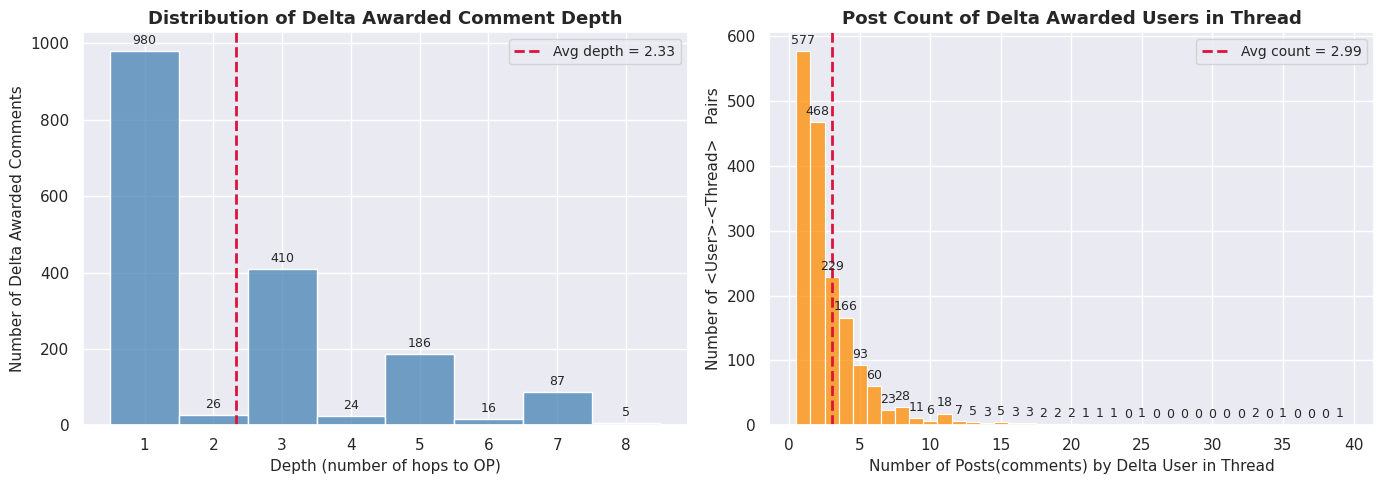

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='darkgrid', palette='muted')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=df_depth,
    x='depth',
    discrete=True,
    color='steelblue',
    edgecolor='white',
    ax=ax1
)
ax1.bar_label(ax1.containers[0], fontsize=9, padding=3)
ax1.axvline(df_depth_mean, color='crimson', linewidth=2, linestyle='--', label=f'Avg depth = {df_depth_mean:.2f}')
ax1.set_title('Distribution of Delta Awarded Comment Depth', fontsize=13, fontweight='bold')
ax1.set_xlabel('Depth (number of hops to OP)', fontsize=11)
ax1.set_ylabel('Number of Delta Awarded Comments', fontsize=11)
ax1.legend(fontsize=10)

# Subplot 2: Delta user post count distribution
sns.histplot(
    data=df_persuasive_user_posts,
    x='post_count',
    discrete=True,    
    color='darkorange',
    edgecolor='white',
    ax=ax2
)
ax2.bar_label(ax2.containers[0], fontsize=9, padding=3)
ax2.axvline(df_persuasive_user_posts_mean, color='crimson', linewidth=2, linestyle='--', label=f'Avg count = {df_persuasive_user_posts_mean:.2f}')
ax2.set_title('Post Count of Delta Awarded Users in Thread', fontsize=13, fontweight='bold')
ax2.set_xlabel('Number of Posts(comments) by Delta User in Thread', fontsize=11)
ax2.set_ylabel('Number of <User>-<Thread>   Pairs', fontsize=11)
ax2.legend(fontsize=10)

plt.tight_layout()

---

## Task 3 $-$ Data Analysis
As we now have metrics to base our analysis and interpretation of data patterns on, we can explore the dataset fully. For both subtasks of task 2, analyze and interpret your observations (_5 points each_). For this, you should adhere to the argument structure below:
1. **Claim** $-$ Verbalize and summarize the overall findings from the subtask (*2 points*).
2. **Evidence** $-$ Include specific numbers from task 2. Copy the markdown table from 2.1 into your answer here (*1 point*).
3. **Interpretation** $-$ Reason about why this observation might be happening and what it may mean about persuasive behavior (*2 points*).

<div style="text-align: right"><b>10 points</b></div>

## Answer - Task 3 – Data Analysis


### 2.1 Persuasion Patterns

#### Claim
Around 46% of all threads contain at least one $\Delta$-awarded comment, meaning persuasive and non-persuasive threads are almost same with non-persuasive threads which are slightly more common. Across both groups, persuasive threads show higher OP engagement and substantially higher participation in terms of distinct users. In other words, threads that end in persuasion tend to attract more unique voices and slightly more back and forth with the original poster. Persuasive threads have consistent distinct users and OP responses based on the standard deviation.

#### Evidence
The table below summarises the key statistics for persuasive and non-persuasive threads. Standard deviations(SD) for OP responses are 11.238 (persuasive) and 11.684 (non-persuasive), and for distinct users 42.504 (persuasive) and 26.422 (non-persuasive).

|                |   persuasive |   non-persuasive |
|:---------------|-------------:|-----------------:|
| ratio          |        0.462 |            0.538 |
| OP responses   |       12.363 |           11.050 |
| distinct users |       30.499 |           21.969 |

#### Interpretation
Persuasive threads have higher engagement from both the OP and the broader community. The near equal thread ratio (0.462 vs. 0.538) suggests that success in persuasion is not rare but also not confirmed. The small difference in OP responses suggests that users who gets a $\Delta$ are somewhat more engaged in the discussion with OP. They reply more, which likely means they are giving good answers. The big difference is in distinct user counts. Persuasive threads attract more unique participants andthis increases the probability that at least one person will bring an answer the OP or another user finds it convincing. Standard deviation shows how consistent they are, the lower the value.

### 2.2 Persuasion Effort

#### Claim
$\Delta$-awarded comments are more frequently found at low depths in the thread (average depth = 2.33), with the more being direct replies to the OP (depth 1). Delta-winning users post an average of around 3 times in the thread, indicating that persuasion typically requires a short but meaningful dialogue rather than a single argument.

#### Evidence
- **Depth distribution:** 988 $\Delta$-awarded comments at depth 1, 26 at depth 2, 410 at depth 3, with successively smaller counts at greater depths. Average depth = **2.325**.
- **Post counts of $\Delta$-awarded users:** Overall 5,141 posts across all $\Delta$-user-thread pairs; average posts = **2.991**.
- **Impact ratings ($\Delta$-awarded comments):** impact_votes mean = **22.541**, impact_votes SD = **109.230**; impact_persuasion mean = **15.567**, SD = **28.954**.

#### Interpretation
The strong concentration of $\Delta$ awards at depth 1 (direct replies to the OP) shows that successful persuasion almost always happens in direct conversation with the OP. As threads deepen and branch, arguments are less likely to change the OP's mind maybe because those exchanges are between other commenters, or because the OP simply pays less attention to deeply nested subthreads. The average of 3 posts per user suggests that persuasion might require user to engage in a short back and forth, perhaps clarifying their argument or responding to the OP's objections before the OP is convinced. The high standard deviation in impact votes (109.2 vs. mean 22.5) indicates that most $\Delta$-winning comments receive modest upvotes, while a small number having high or low votes. The impact_persuasion mean (15.6) suggests that users with an track record of persuading others (as reflected by their flair score) are somewhat more likely to get $\Delta$ points.